<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week10/calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
#Packages load
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from PIL import Image
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [8]:
#Image Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [10]:
class CarlaDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
#Evaluation function
def evaluate_model(model_file, label_column):

    # Create dataset
    val_dataset = CarlaDataset(
        test_path,
        label_column=label_column,
        transform=transform
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    # Create model
    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    # Load weights
    model.load_state_dict(
        torch.load(model_file, map_location=device)
    )

    model = model.to(device)

    model.eval()

    # Prediction lists
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels_batch.numpy())


    # Flatten predictions
    all_preds = [p[0] for p in all_preds]

    # Metrics
    cm = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1, cm

In [18]:
def compute_ece(y_true, y_prob, n_bins=10):

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        mask = (
            (y_prob >= bins[i]) &
            (y_prob < bins[i+1])
        )

        if np.sum(mask) > 0:

            accuracy = np.mean(
                y_true[mask]
            )

            confidence = np.mean(
                y_prob[mask]
            )

            ece += (
                np.sum(mask) /
                len(y_true)
            ) * abs(
                accuracy - confidence
            )

    return ece

In [3]:
def plot_reliability_diagram(
    y_true,
    y_prob,
    n_bins=10
):

    bins = np.linspace(0,1,n_bins+1)

    accuracies = []
    confidences = []

    for i in range(n_bins):

        mask = (
            (y_prob >= bins[i]) &
            (y_prob < bins[i+1])
        )

        if np.sum(mask) > 0:

            accuracy = np.mean(
                y_true[mask] ==
                (y_prob[mask] >= 0.5)
            )

            confidence = np.mean(
                y_prob[mask]
            )

            accuracies.append(accuracy)
            confidences.append(confidence)

    plt.figure(figsize=(6,6))

    plt.plot(
        [0,1],
        [0,1],
        "--",
        label="Perfect Calibration"
    )

    plt.plot(
        confidences,
        accuracies,
        marker="o",
        label="Model"
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")

    plt.title(
        "Reliability Diagram"
    )

    plt.legend()

    plt.show()

In [13]:
def evaluate_calibration(
    model_file,
    label_column,
    test_path
):

    val_dataset = CarlaDataset(
        test_path,
        label_column=label_column,
        transform=transform
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    model = models.resnet18(
        pretrained=True
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(
            model_file,
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(
                outputs
            )

            all_probs.extend(
                probs.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy()
            )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    ece = compute_ece(
        all_labels,
        all_probs
    )

    print("ECE:", round(ece,4))

    plot_reliability_diagram(
        all_labels,
        all_probs
    )

    return ece

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ECE: 0.0992


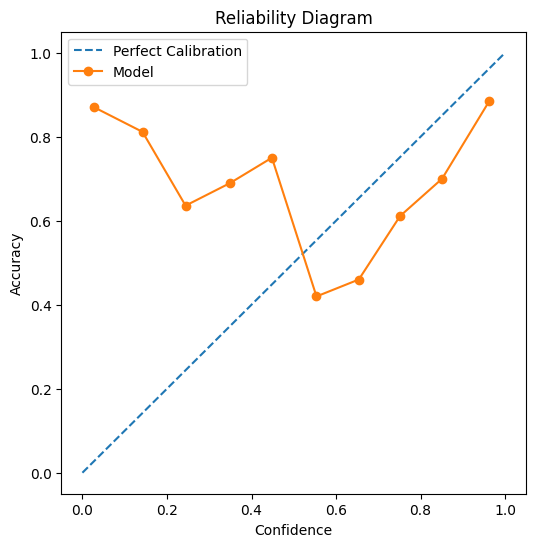

In [19]:
ped_ece = evaluate_calibration(
   "/content/drive/MyDrive/MLS/pedestrian_model.pth",
    "has_pedestrian",
   "/content/drive/MyDrive/MLS/test"

)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ECE: 0.1069


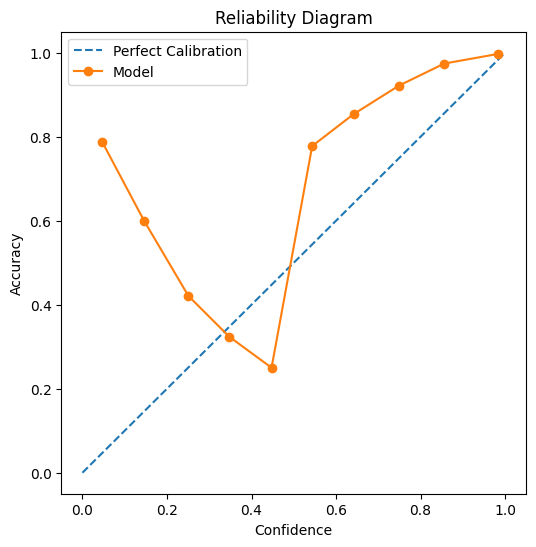

In [20]:
veh_ece = evaluate_calibration(
    "/content/drive/MyDrive/MLS/Vehicle_model.pth",
    "has_vehicle",
    "/content/drive/MyDrive/MLS/test"

)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ECE: 0.035


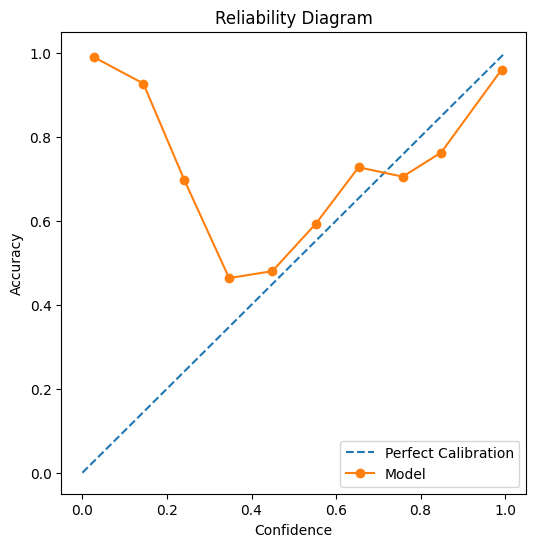

In [21]:
traffic_ece = evaluate_calibration(
    "/content/drive/MyDrive/MLS/Traffic_Light_model.pth",
    "has_traffic_light",
    "/content/drive/MyDrive/MLS/test"
)